# Meeting 11, Act 1: A Layer of Neurons Is a Matrix

**CS 301, Introduction to Data Science, NJIT.** Unit II, meeting 11.

In meeting 10 a dataset became a matrix, with one row for each point. An artificial **neuron** is a rule that converts a point of the data into one number, its score. In this act neurons become a matrix as well, with one row for each neuron, and applying the neurons to the data becomes one product of two matrices. Your group applies neurons to the pixels of its image and, at the end, repaints the image with them.

## How this lab works

- **This is the full notebook of Act 1 of meeting 11.** In class, the slides and the class notebook covered the act in short. This notebook explains every step, with checks that test your code, and holds the work for after the meeting.
- **Work in a group of two or three.** Each member opens this notebook and runs it. First open the **File** menu and choose **Save a copy in Drive**, so that your changes are kept.
- **Run the cells in order**, from the top. To run a cell, click it and press **Shift + Enter**.
- A paragraph that begins with <font color="#c00000"><b>Your turn</b></font> asks you to do something before you go on.
- A code cell under the word **Check** tests your work and prints a message. If the message reports a problem, fix it before you go on.
- In Step 6 you ask an **AI assistant** to write code. Paste the prompt you used into the cell marked <font color="#c00000"><b>Our prompt</b></font>, so that the notebook records how the code was made.
- **The posts of the meeting were made in class**, from the class notebook. If your group did not post for an act, the paragraph marked <font color="#c00000"><b>Post</b></font> in this notebook says what to post.
- **Keep this notebook open when Act 1 ends.** Act 2 asks for your function `softmax_rows` and for the paints of your group.
- **After the meeting**, **Review Quiz 11** on Canvas asks about this lab. Where the notebook says that the quiz asks about a point, read that part again before you take the quiz.

<font color="#c00000" size="5"><b>Your turn.</b></font> Double-click this cell and replace this line with the names of the members of your group.

In [1]:
#Kushi Patel Ananya Sudireddy
# Setup. Run this cell first.
import ast
import inspect
import textwrap
import time
from urllib.request import urlopen

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

# The address of the course's files for this unit, and of the folder that holds the images.
SITE = "https://ikoutis.github.io/cs301-labs/unit-2/"
IMAGES = SITE + "images/"


def read_image(file):
    """Read an image file into a NumPy array with values from 0 to 1."""
    return np.array(Image.open(urlopen(IMAGES + file))) / 255.0


def show(pictures, titles):
    """Draw arrays as pictures: an array with two dimensions in grey, one with three in colour."""
    columns = 2 if len(pictures) == 4 else len(pictures)
    lines = len(pictures) // columns
    fig, axes = plt.subplots(lines, columns, figsize=(5 * columns, 4.2 * lines), squeeze=False)
    for ax, picture, title in zip(axes.flat, pictures, titles):
        ax.imshow(np.clip(picture, 0, 1), cmap="gray", vmin=0, vmax=1)
        ax.set_title(title)
    fig.tight_layout()
    plt.show()


def show_colours(colours, names, title):
    """Draw colours as a row of squares, each under its name."""
    fig, axes = plt.subplots(1, len(colours), figsize=(1.7 * len(colours), 2.0), squeeze=False)
    for ax, colour, name in zip(axes.flat, colours, names):
        ax.imshow(np.clip(colour, 0, 1).reshape(1, 1, 3))
        ax.set_title(name, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
    fig.suptitle(title, fontsize=11)
    fig.tight_layout()
    plt.show()


def reference_colours(X, K=5, rounds=10):
    """K colours that occur often among the rows of X, from the darkest to the lightest."""
    grey_weights = np.array([0.299, 0.587, 0.114])
    sample = X[::7]                                    # every seventh point is enough
    order = np.argsort(sample @ grey_weights)          # the points, from the darkest to the lightest
    C = np.array([sample[part].mean(axis=0) for part in np.array_split(order, K)])
    for _ in range(rounds):                            # a few rounds of the method k-means
        distance = ((sample[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
        nearest = distance.argmin(axis=1)
        for j in range(K):
            if (nearest == j).any():
                C[j] = sample[nearest == j].mean(axis=0)
    return C[np.argsort(C @ grey_weights)]


def has_loop(function):
    """True when the text of the function contains a loop."""
    try:
        tree = ast.parse(textwrap.dedent(inspect.getsource(function)))
    except (OSError, TypeError, SyntaxError):
        return False
    loops = (ast.For, ast.While, ast.ListComp, ast.SetComp, ast.DictComp, ast.GeneratorExp)
    return any(isinstance(node, loops) for node in ast.walk(tree))


def mentions(function, words):
    """True when the text of the function contains one of the words."""
    try:
        text = inspect.getsource(function)
    except (OSError, TypeError):
        return False
    return any(word in text for word in words)


print("Setup is done.")

Setup is done.


## <font color="#1967d2"><b>Step 1: One neuron, one point</b></font>

A **neuron** is a rule that converts one point into one number. It has one **weight** for each coordinate of the point, and one more number, its **bias**. For a point $x$ with $m$ coordinates, the neuron with weights $w$ and bias $b$ computes the **score**

$$s = w_1 x_1 + w_2 x_2 + \dots + w_m x_m + b,$$

and the neuron **fires** when $s \ge 0$. In words: every coordinate of the point is multiplied by its weight, and the products and the bias are added. Neural networks are built from many such rules.

In this act a point is one **pixel** of your group's image, with $m = 3$ coordinates: its red, its green and its blue number. What counts as a point depends on the question that is asked. In Step 16 of meeting 10 a whole image was one point. The questions of this act are about colours, so here a point is one pixel.

You have already used a neuron on pixels. The grey rule of meeting 10 is the neuron with the weights 0.299, 0.587 and 0.114 and the bias 0: its score is the brightness of the pixel.

<font color="#c00000" size="5"><b>Your turn.</b></font> Every member types the group's number in the next cell, in place of the `0`, and runs the cell. Use the number that your group had in meeting 10, so that you work on the same image. If your group has no number, choose any number from 1 to 30.

Image 3: Water Lilies (Claude Monet)
shape of image: (614, 640, 3), which is 614 rows and 640 columns of pixels


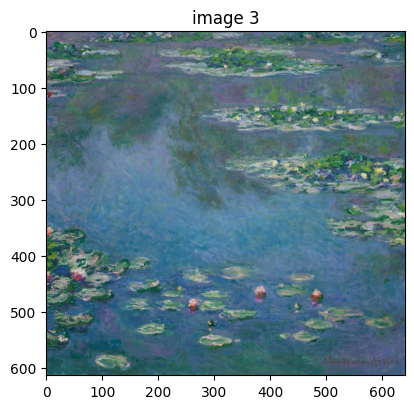

the pixel   x = [0.38 0.53 0.64]  (red, green, blue)
the weights w = [0.299 0.587 0.114]  and the bias b = 0.0


In [2]:
IMAGE = 3        # replace 0 with your group's number, from 1 to 30

assert 1 <= IMAGE <= 30, "Type your group's number in place of the 0."

images = pd.read_csv(IMAGES + "images.csv", index_col="number")
picture_info = images.loc[IMAGE]
image = read_image(picture_info["file"])
height, width = image.shape[0], image.shape[1]
print(f"Image {IMAGE}: {picture_info['title']} ({picture_info['creator']})")
print(f"shape of image: {image.shape}, which is {height} rows and {width} columns of pixels")
show([image], [f"image {IMAGE}"])

x = image[height // 2, width // 2]             # the pixel in the middle of the image
w_grey = np.array([0.299, 0.587, 0.114])       # the weights of the grey neuron
b_grey = 0.0                                   # its bias
print("the pixel   x =", np.round(x, 2), " (red, green, blue)")
print("the weights w =", w_grey, " and the bias b =", b_grey)

<font color="#c00000" size="5"><b>Your turn.</b></font> Compute the score of the grey neuron on your pixel, by hand or with a calculator, from the numbers that the cell printed: three products, their sum, and the bias. Write the score in the next cell. Then run the cell after it. The printed pixel is rounded to two decimals, so your score may differ from the computed one in the third decimal.

<font color="#c00000" size="5"><b>Our score:0.493</b></font> Double-click this cell and replace this line with the score you computed.

In [3]:
s_one = w_grey @ x + b_grey          # the dot product of the weights and the point, plus the bias
print(f"s = {s_one:.3f}")
print("shape of w_grey:", w_grey.shape, "  shape of x:", x.shape)

s = 0.493
shape of w_grey: (3,)   shape of x: (3,)


**The same score, written with matrices.** In linear algebra the point $x$ and the weights $w$ are **columns**: matrices with $m$ rows and 1 column. The **transpose** of $w$, written $w^{\mathsf T}$, holds the same numbers as a **row**: 1 row and $m$ columns. A row times a column is one number, the sum of the products of matching entries. So

$$s = w^{\mathsf T} x + b.$$

The shapes show why the transpose is there. $w^{\mathsf T}$ is 1 × m and $x$ is m × 1, so their product is 1 × 1: a single number. The bias $b$, a single number too, is added to it. Without the transpose the product would be (m × 1) times (m × 1), which is not defined.

**In NumPy** the arrays `w_grey` and `x` have **one** dimension: their shape is `(3,)`. An array with one dimension is neither a row nor a column, and `@` between two such arrays is their dot product.

<font color="#c00000" size="5"><b>Your turn.</b></font> Before you run the next cell, predict: what is the shape of `w_grey.T`, the transpose of `w_grey`?

In [4]:
print("shape of w_grey.T:", w_grey.T.shape, "- an array with one dimension is its own transpose")

w_column = w_grey.reshape(3, 1)      # the same numbers as a matrix with 3 rows and 1 column
x_column = x.reshape(3, 1)
print("shape of w_column:", w_column.shape, "  shape of w_column.T:", w_column.T.shape)
print("w_column.T @ x_column =", w_column.T @ x_column, "- a matrix with 1 row and 1 column")
try:
    w_column @ x_column
except ValueError:
    print("w_column @ x_column fails: a matrix with 1 column cannot be multiplied by a matrix with 3 rows")

shape of w_grey.T: (3,) - an array with one dimension is its own transpose
shape of w_column: (3, 1)   shape of w_column.T: (1, 3)
w_column.T @ x_column = [[0.49345098]] - a matrix with 1 row and 1 column
w_column @ x_column fails: a matrix with 1 column cannot be multiplied by a matrix with 3 rows


## <font color="#1967d2"><b>Step 2: One neuron, many points</b></font>

`image.reshape(-1, 3)` writes the pixels of the image as the rows of a matrix `X`: **n points with m = 3 coordinates each**, like the dataset of meeting 10. Here n = height × width.

The grey neuron gives every point a score: $s_i = w^{\mathsf T} x_i + b$ for the point $x_i$ in row $i$. One product computes all the scores:

$$s = Xw + b\,\mathbf{1}.$$

- $X$ is n × m and $w$ is m × 1, so $Xw$ is n × 1: one score for each point. Its entry $i$ is row $i$ of $X$ times $w$. Row $i$ of $X$ is the point $x_i$ written as a row, which is $x_i^{\mathsf T}$, and $x_i^{\mathsf T} w$ is the same number as $w^{\mathsf T} x_i$. **The transpose has moved from the weights to the point, because the data stores each point as a row.**
- $\mathbf{1}$ is a column of n ones. The mathematics needs it in order to add the single number $b$ to each of the n scores. In NumPy, `X @ w + b` adds `b` to every entry of `X @ w`. This is **broadcasting**, as in `v + 10` of meeting 10.

In [ ]:
X = image.reshape(-1, 3)                 # one row for each pixel
n, m = X.shape
print(f"shape of X: {X.shape}, which is n = {n:,} points with m = {m} coordinates")

s_grey = X @ w_grey + b_grey             # the scores of the grey neuron on all the points
print("shape of X @ w_grey + b_grey:", s_grey.shape)
print("the scores of the first five points:", np.round(s_grey[:5], 3))

grey = read_image(picture_info["grey_file"])           # the grey image of meeting 10
difference = np.abs(s_grey.reshape(height, width) - grey).max()
print(f"largest difference between the scores and the grey image of meeting 10: {difference:.4f}")
show([image, s_grey.reshape(height, width)], ["the image", "the scores of the grey neuron"])

**How to read the result.** `s_grey.reshape(height, width)` puts the n scores back at the places of their pixels. The picture of the scores is the grey image of meeting 10: the largest difference from the stored grey image is below 0.005.

**A neuron that fires.** A brightness is never negative, so with the bias 0 the grey neuron fires on every pixel. A negative bias makes it fire on some pixels only. The number $\theta = -b$ is called the **threshold** of the neuron: the neuron fires when the weighted sum of the coordinates reaches it. The next cell sets the bias to minus the mean brightness of your image: the neuron then fires on the pixels that are brighter than the average pixel.

In [ ]:
b_bright = -s_grey.mean()                        # minus the mean brightness of the image
fires = X @ w_grey + b_bright >= 0               # True for the points on which the neuron fires
print(f"bias {b_bright:.3f}: the neuron fires on {fires.mean():.1%} of the {n:,} pixels")
show([image, fires.reshape(height, width).astype(float)], ["the image", "white where the neuron fires"])

<font color="#c00000" size="5"><b>Your turn.</b></font> Make a neuron of your own. In the next cell, change the three weights and the bias so that the neuron fires on a kind of pixel that your group chooses: for example the reddish pixels, the bluish pixels or the dark pixels. The numbers that are in the cell now make a neuron that fires when the red number of a pixel exceeds the average of its green and its blue number by at least 0.1. Run the cell after each change, until the white region is the one you want. Then say in the cell after it, in one sentence, on which pixels your neuron fires.

In [ ]:
w_own = np.array([1.0, -0.5, -0.5])      # the weights for red, green and blue
b_own = -0.1                             # the bias

fires_own = X @ w_own + b_own >= 0
print(f"weights {w_own}, bias {b_own}: the neuron fires on {fires_own.mean():.1%} of the pixels")
show([image, fires_own.reshape(height, width).astype(float)], ["the image", "white where our neuron fires"])

<font color="#c00000" size="5"><b>Our answer.</b></font> Double-click this cell and replace this line with one sentence: on which pixels does your neuron fire?

**Two ways to store the points.** In this course, as in pandas, NumPy and PyTorch, a point is a **row** of $X$, and the scores of a neuron are $Xw + b$. Many books store a point as a **column** instead. Their data matrix has m rows and n columns: it is the transpose of ours, and with it the same scores are written $w^{\mathsf T} X + b$. The next cell computes the scores in both ways.

In [ ]:
by_rows = X @ w_grey + b_bright          # points as rows: X has shape (n, m)
by_columns = w_grey @ X.T + b_bright     # points as columns: X.T has shape (m, n)
print("shape of X:", X.shape, "  shape of X.T:", X.T.shape)
print("The two results are equal:", np.allclose(by_rows, by_columns))
try:
    w_grey @ X
except ValueError:
    print(f"w_grey @ X fails: w_grey has 3 entries and X has {n:,} rows, so the shapes do not fit")

## <font color="#1967d2"><b>Step 3: Many neurons, one point</b></font>

A **layer** is a set of neurons that read the same point, each with its own weights and its own bias. A layer of K neurons is stored as

- a matrix `W` with K rows and m columns: **row j holds the weights of neuron j**, in the same way as a row of `X` holds a point;
- an array `b` with K numbers: the bias of each neuron.

The K scores of one point $x$ are

$$s = Wx + b.$$

$W$ is K × m and $x$ is m × 1, so $Wx$ is K × 1, and $b$ is K × 1 as well. Entry $j$ of the result is $w_j^{\mathsf T} x + b_j$, the score of neuron $j$. This time the sum is between two columns of the same shape: **the formula works as it is written, and nothing has to be repeated.**

**The neurons of this act.** The next cell asks the setup for K = 5 **reference colours** of your image: five colours that occur often in it. (The setup finds them with a method called k-means; how it works does not matter here.) Each neuron belongs to one reference colour. The weights of neuron $j$ are the three numbers of its colour $c_j$, and its bias is $b_j = -\tfrac{1}{2}\left(c_{j1}^2 + c_{j2}^2 + c_{j3}^2\right)$, minus half the sum of their squares. With these numbers, **the neuron with the largest score is the neuron whose colour is nearest to the pixel**. Review Quiz 11 asks you to show why.

In [ ]:
K = 5
C = reference_colours(X, K)              # K rows and 3 columns: the reference colours, darkest first
W = C.copy()                             # the weights of the layer: row j is reference colour j
b = -0.5 * (C ** 2).sum(axis=1)          # the biases of the layer: one number for each neuron

print("shape of W:", W.shape, "  shape of b:", b.shape)
print("W =")
print(np.round(W, 2))
print("b =", np.round(b, 2))
show_colours(C, [f"neuron {j}" for j in range(K)], "The reference colours: row j of W")

The next cell applies the layer to the pixel `x` of Step 1. Positions are counted from 0, so the neurons are numbered 0 to 4.

In [ ]:
s_x = W @ x + b                          # the K scores of the pixel x
print("the pixel x =", np.round(x, 2))
print("shape of W @ x + b:", s_x.shape)
print("the scores of the", K, "neurons:", np.round(s_x, 3))
best = int(s_x.argmax())                 # the position of the largest score
print(f"The largest score is that of neuron {best}, whose colour is {np.round(C[best], 2)}.")
show_colours(np.array([x, C[best]]), ["the pixel x", f"colour of neuron {best}"],
             "The pixel, and the colour with the largest score")

## <font color="#1967d2"><b>Step 4: Many neurons, many points</b></font>

Now every neuron is applied to every point. The result is a matrix `S` of scores with n rows and K columns: **row i belongs to point i, and column j belongs to neuron j**. The entry `S[i, j]` is the score of neuron j on point i.

The function `layer_loops` in the next cell computes these scores from their definition, with three nested loops: over the points, over the neurons, and over the coordinates. The cell runs it on the first 2,000 points only.

In [ ]:
def layer_loops(X, W, b):
    """The scores of the K neurons of a layer on the n points of X, one multiplication at a time."""
    n, m = X.shape
    K = W.shape[0]
    S = np.empty((n, K))
    for i in range(n):                   # every point
        for j in range(K):               # every neuron
            total = b[j]
            for c in range(m):           # every coordinate
                total += W[j, c] * X[i, c]
            S[i, j] = total
    return S


S_first = layer_loops(X[:2000], W, b)
print("shape of the scores of the first 2,000 points:", S_first.shape)

<font color="#c00000" size="5"><b>Your turn.</b></font> The three loops are one product of matrices. Complete the function `layer` in the next cell: replace the three dots with **one line** that uses `@` and no loop. You have seen `X @ w + b` for one neuron on many points, and `W @ x + b` for many neurons on one point. Mind the shapes: `X` is (n, m) and `W` is (K, m).

In [ ]:
def layer(X, W, b):
    """The scores of the K neurons of a layer on the n points of X: an array with n rows and K columns."""
    return ...      # Your turn: replace the three dots with one line that uses @

**Check.** The next cell runs your function on all the points and compares the first 2,000 rows with the result of the three loops.

In [ ]:
try:
    S = layer(X, W, b)
except ValueError:
    raise AssertionError(
        "The shapes do not fit. X has shape (n, 3) and W has shape (K, 3), and the result must have n rows "
        "and K columns. Which array has to be transposed?") from None
assert S is not ..., "Replace the three dots in the function layer with your line, and run that cell again."
S = np.asarray(S)
assert S.shape == (n, K), (
    f"layer returned an array of shape {S.shape}. It must be {(n, K)}: one row for each point and one column for each neuron.")
assert np.allclose(S[:2000], S_first), (
    "The scores differ from those of layer_loops. Check which array is transposed, and that the bias is added.")
print(f"Correct: layer(X, W, b) has shape {S.shape} and agrees with the three loops.")

**The same scores, written with matrices.**

$$S = XW^{\mathsf T} + \mathbf{1}\,b^{\mathsf T}$$

- $X$ is n × m and $W^{\mathsf T}$ is m × K, so the product is n × K. **$W$ is transposed because a neuron is stored as a row of $W$, and the product needs the weights of each neuron as a column.** Row $i$ of $S$ holds the K scores of point $i$: it is the column $Wx_i + b$ of Step 3, written as a row.
- $\mathbf{1}\,b^{\mathsf T}$ is the row $b^{\mathsf T}$ written again on each of the n rows. In NumPy, `+ b` does this by broadcasting, as `X - mu` did in meeting 10.

The shapes do not always warn of a missing transpose. When a layer has as many neurons as a point has coordinates, K = m, the line `X @ W + b` runs without an error, and its numbers are wrong.

The four cases of this act, in NumPy:

| | one point `x`, shape (m,) | n points `X`, shape (n, m) |
|---|---|---|
| **one neuron:** `w` of shape (m,), `b` a number | `w @ x + b` is a number | `X @ w + b` has shape (n,); `b` is broadcast |
| **K neurons:** `W` of shape (K, m), `b` of shape (K,) | `W @ x + b` has shape (K,) | `X @ W.T + b` has shape (n, K); `b` is broadcast |

The next cell measures the three loops and the product on all the points of your image. It takes a few seconds.

In [ ]:
start = time.perf_counter()
S_loops = layer_loops(X, W, b)
t_loops = time.perf_counter() - start

start = time.perf_counter()
for _ in range(20):
    S = layer(X, W, b)
t_product = (time.perf_counter() - start) / 20

print(f"n = {n:,} points, m = {m} coordinates, K = {K} neurons")
print(f"The innermost line of the loops runs n x K x m = {n * K * m:,} times.")
print(f"{'version':16s}{'seconds':>12s}")
print(f"{'three loops':16s}{t_loops:12.4f}")
print(f"{'one product':16s}{t_product:12.4f}")
print(f"The loops take {t_loops / t_product:.0f} times as long as the product.")

Act 3 of this meeting comes back to the number n × K × m.

**The neuron with the largest score.** When each neuron of a layer stands for one possible answer, the answer of the layer for a point is the neuron with the largest score. The position of the largest entry of a row is called its **argmax**. `S.argmax(axis=1)` finds it for every row of `S`: the neuron with the largest score for that point. `C[winner]` then takes, for every point, the reference colour of that neuron.

In [ ]:
winner = S.argmax(axis=1)                # for each point, the neuron with the largest score
print("shape of winner:", winner.shape, "  its first ten entries:", winner[:10])
shares = np.bincount(winner, minlength=K) / n
for j in range(K):
    print(f"neuron {j}, colour {np.round(C[j], 2)}: the largest score on {shares[j]:.1%} of the pixels")
show([image, C[winner].reshape(height, width, 3)],
     ["the image", f"every pixel in the colour of its neuron: {K} colours"])

## <font color="#1967d2"><b>Step 5: The sigmoid, a function of every entry</b></font>

A neuron fires or it does not. The **sigmoid** is a function that replaces "fires or not" by a number between 0 and 1:

$$\sigma(s) = \frac{1}{1 + e^{-s}}.$$

In words: 1 divided by 1 plus the exponential of minus the score. The sigmoid of a score of 0 is 0.5, a large positive score gives a number near 1, and a large negative score a number near 0.

On an array, `1 / (1 + np.exp(-s))` applies the function to **every entry**. It is a pointwise operation, like `grey ** 2` in meeting 10, and its result has the shape of its input, whatever that shape is.

The next cell applies the sigmoid to the n scores of your own neuron of Step 2. It also divides the scores by a positive number T first, which is called the **temperature**: a small T brings the sigmoid close to "fires or not".

In [ ]:
def sigmoid(s):
    """The sigmoid of every entry of the array s."""
    return 1 / (1 + np.exp(-s))


s_own = X @ w_own + b_own                # the scores of your own neuron of Step 2 on all the points
T = 0.05                                 # the temperature

print("shape of s_own:", s_own.shape, " shape of sigmoid(s_own):", sigmoid(s_own).shape)
print("shape of S:    ", S.shape, " shape of sigmoid(S):    ", sigmoid(S).shape)
print(f"sigmoid(s_own) lies between {sigmoid(s_own).min():.2f} and {sigmoid(s_own).max():.2f}")
print(f"sigmoid(s_own / T) lies between {sigmoid(s_own / T).min():.2f} and {sigmoid(s_own / T).max():.2f}")
show([sigmoid(s_own).reshape(height, width), sigmoid(s_own / T).reshape(height, width),
      (s_own >= 0).reshape(height, width).astype(float)],
     ["sigmoid(s_own)", f"sigmoid(s_own / T), with T = {T}", "fires or not"])

**How to read the pictures.** Each picture has one value for each pixel, from 0 (black) to 1 (white). The scores of a neuron on pixels are small numbers, so in the first picture the values stay in a narrow range around 0.5. Dividing the scores by a small temperature spreads them out, and the second picture approaches the third, in which the neuron only fires or not.

## <font color="#1967d2"><b>Step 6: The softmax, a function of every row</b></font>

The **softmax** turns the K scores of one point into K positive numbers that add to 1. They are read as probabilities, one for each neuron: the larger a score is beside the other scores of the point, the larger its probability.

$$p_k = \frac{e^{s_k}}{e^{s_1} + e^{s_2} + \dots + e^{s_K}}.$$

In words: the exponential of the score of neuron k, divided by the sum of the exponentials of all the K scores of the point.

The sigmoid changes each entry by itself. The softmax does not: every entry of its result depends on **all the entries of its row**, because the entries of a row share one denominator. Applied to the matrix `S`, the softmax treats each row separately. It returns a matrix of the same shape, n × K, in which every row adds to 1.

<font color="#c00000" size="5"><b>Your turn.</b></font> Ask an AI assistant to write the function. You may use the assistant built into Colab or any other. Your prompt must state all of these requirements:

- the function is named `softmax_rows` and takes one argument, `S`, a NumPy array with n rows and K columns;
- it returns an array of the same shape, in which every row is the softmax of the same row of `S`;
- it uses operations on whole arrays: **no loop**, and no softmax function from a library;
- before it takes the exponential, it subtracts from every row the largest entry of that row. Adding the same number to all the scores of a point leaves its probabilities as they were: every exponential is multiplied by the same factor, which cancels in the division. After the subtraction no exponential is larger than 1, so no number becomes too large for the computer.

Paste your prompt into the next cell, and the function into the code cell after it.

**Read the function before you run it.** Find where it says `axis=1` and where it says `keepdims=True`. Review Quiz 11 asks what each of them does.

<font color="#c00000" size="5"><b>Our prompt.</b></font> Double-click this cell and replace this line with the prompt you gave to the AI assistant.

In [ ]:
# Your turn: paste the function softmax_rows here, then run this cell.

**Check.** The next cell tests your function on three rows of scores. The first row holds the scores −1, 0, 2 and 1, whose softmax is 0.03, 0.09, 0.64 and 0.24. The last row holds very large scores.

In [ ]:
assert "softmax_rows" in globals(), "Paste the function softmax_rows into the cell above and run that cell."
assert not has_loop(softmax_rows), "This function must use operations on whole arrays: no loop."
assert not mentions(softmax_rows, ("scipy", "torch", "sklearn")), (
    "This function must compute the softmax itself, with NumPy only: no softmax function from a library.")

test = np.array([[-1.0, 0.0, 2.0, 1.0],
                 [0.0, 0.0, 0.0, 0.0],
                 [1000.0, 1003.0, 1001.0, 1002.0]])
expected = np.array([[0.0321, 0.0871, 0.6439, 0.2369],
                     [0.25, 0.25, 0.25, 0.25],
                     [0.0321, 0.6439, 0.0871, 0.2369]])
try:
    with np.errstate(all="ignore"):
        result = np.asarray(softmax_rows(test.copy()), dtype=float)
except ValueError:
    raise AssertionError(
        "The shapes inside softmax_rows do not fit. The largest entry and the sum of every row must keep "
        "the shape (n, 1), so that they can be combined with the n rows: use keepdims=True.") from None
assert result.shape == test.shape, f"softmax_rows returned an array of shape {result.shape}; it must be {test.shape}."
assert not np.isnan(result).any(), (
    "softmax_rows returns nan (not a number) for the row of very large scores. "
    "Subtract the largest entry of each row before the exponential.")
assert np.allclose(result.sum(axis=1), 1), (
    "The rows of the result do not add to 1. The largest entry and the sum must be taken along each row: axis=1.")
assert np.allclose(result, expected, atol=2e-4), (
    f"The result is not the softmax of the rows. For the scores -1, 0, 2, 1 the function gives {np.round(result[0], 2)}; "
    "the right values are 0.03, 0.09, 0.64, 0.24.")
print("Correct: every row of the result adds to 1, also for very large scores.")
print("The scores -1, 0, 2, 1 give", np.round(result[0], 2))

The next cell applies your function to the scores of all the points. As in Step 5, the scores are divided by a temperature first. The scores of this layer are small numbers, so a temperature well below 1 is needed before one neuron clearly wins.

In [ ]:
T = 0.02                                 # the temperature of the softmax
Prob = softmax_rows(S / T)               # n rows and K columns: the probabilities
print("shape of Prob:", Prob.shape)
print("the scores of the point in row 0:       ", np.round(S[0], 3))
print(f"its probabilities at temperature {T}: ", np.round(Prob[0], 3))
print("the sum of its probabilities:", round(float(Prob[0].sum()), 6))

## <font color="#1967d2"><b>Step 7: Repaint your image</b></font>

A second product turns the K probabilities of a pixel back into a colour. Give every neuron a **paint**: a colour of your choice, written as three numbers from 0 to 1 for red, green and blue. The paints are the rows of a matrix `PAINT` with K rows and 3 columns. Then

`new = Prob @ PAINT`

has n rows and 3 columns. The new colour of a pixel is a mixture of the K paints, in which each paint counts with the probability of its neuron. The whole computation is two lines:

```
Prob = softmax_rows(layer(X, W, b) / T)      # scores, then probabilities
new = Prob @ PAINT                           # probabilities, then colours
```

The second product is of the same kind as the first: n points, now with K coordinates each, and three neurons, one for each number of the new colour. Two layers with a function between them are a small **neural network**. Here the network is applied to all the pixels of the image at once.

In [ ]:
PAINT = np.array([[0.10, 0.07, 0.30],      # the paint of neuron 0, the neuron of the darkest reference colour
                  [0.80, 0.10, 0.35],      # the paint of neuron 1
                  [0.98, 0.55, 0.15],      # the paint of neuron 2
                  [0.99, 0.85, 0.40],      # the paint of neuron 3
                  [1.00, 1.00, 0.92]])     # the paint of neuron 4, the neuron of the lightest reference colour
T = 0.02                                   # the temperature of the softmax

assert PAINT.shape == (K, 3), f"PAINT must have {K} rows, one for each neuron, and 3 columns."
Prob = softmax_rows(layer(X, W, b) / T)    # n rows and K columns
new = Prob @ PAINT                         # n rows and 3 columns
print("shape of Prob:", Prob.shape, "  shape of PAINT:", PAINT.shape, "  shape of new:", new.shape)

show_colours(PAINT, [f"paint {j}" for j in range(K)], "The paints: row j of PAINT is the paint of neuron j")
show([image, new.reshape(height, width, 3)], ["the image", f"repainted, at temperature {T}"])

paints = "; ".join(str(tuple(float(v) for v in np.round(paint, 2))) for paint in PAINT)
print("Line for the discussion board:")
print(f"Image {IMAGE} ({picture_info['title']}), repainted with {K} paints at temperature {T}. "
      f"Paints (red, green, blue): {paints}.")

<font color="#c00000" size="5"><b>Your turn.</b></font> Make the picture your own.

1. Replace the five paints with colours that your group chooses.
2. Run the cell with the temperatures 1, 0.1 and 0.002 before you settle on one. What does the temperature change in the picture?

<font color="#c00000" size="5"><b>Post.</b></font> In class, your group posted this from the class notebook. If it did not, one member posts now, for the whole group, on the discussion board of this meeting. Begin the post with the names of all the members of your group. The post contains:

- the line that the cell printed under the pictures;
- the picture of your image beside its repainted version. To save the figure, right-click it and choose **Save image as**;
- under the picture, **one sentence that says what it shows**, so that a classmate who cannot see the picture still gets the result;
- one sentence on what the temperature changed.

**Review Quiz 11** asks you to explain, for one pixel, how the two lines turn its three numbers into its new colour.

## <font color="#1967d2"><b>Step 8: The same line on other data</b></font>

The line `X @ W.T + b` does not depend on what the points are.

- **Days.** A layer of four neurons, one for each season, reads the m = 2 coordinates of a day: its high and its low temperature at Newark airport. Its weights are a matrix with K = 4 rows and 2 columns. Nobody chose these weights by hand. A program adjusted them in many small steps, until the layer named the right season for as many days of the years 2006 to 2017 as it could. This is called **training** a layer. The next cell applies the trained layer to the n = 1,457 days of the years 2018 to 2021, which it has not seen.
- **Words.** In meeting 10, `U @ v` computed the similarity of 50,000 words to one word. It was one neuron, whose weights were the vector of that word, applied to n = 50,000 points with m = 50 coordinates.

In [ ]:
weather = pd.read_csv(SITE + "weather/newark-weather.csv")
# the days with no missing measurement
weather = weather.dropna(subset=["tmax_f", "tmin_f", "humidity_pct", "pressure_hpa"])
days = weather[weather["date"].str[:4].isin(["2018", "2019", "2020", "2021"])]
month = days["date"].str[5:7].astype(int).to_numpy()
season = (month % 12) // 3               # 0 winter (December to February), 1 spring, 2 summer, 3 fall

X_days = days[["tmax_f", "tmin_f"]].to_numpy()               # the high and the low of each day
mu, sd = np.array([64.7888, 47.9889]), np.array([18.5731, 16.9396])
Z_days = (X_days - mu) / sd                                  # standardized, as in meeting 10

W_seasons = np.array([[-1.35750, -1.96665],      # the neuron of winter
                      [ 0.54402, -1.21157],      # the neuron of spring
                      [ 0.92758,  3.07303],      # the neuron of summer
                      [-0.11410,  0.10518]])     # the neuron of fall
b_seasons = np.array([-0.64726, 1.19295, -1.73890, 1.19321])

S_days = Z_days @ W_seasons.T + b_seasons        # the line of Step 4
print("shape of Z_days:", Z_days.shape, "  shape of W_seasons:", W_seasons.shape)
print("shape of S_days:", S_days.shape)
right = (S_days.argmax(axis=1) == season).mean()
print(f"The neuron with the largest score names the right season on {right:.1%} of the {len(days):,} days.")

## Act 1 ends here

**Keep this notebook open.** Act 2 asks for your function `softmax_rows` and for the paints of your group.

Act 2 has its own notebook. It is linked in the module of this meeting on Canvas, and here: [open the notebook of Act 2 in Colab](https://colab.research.google.com/github/ikoutis/cs301-labs/blob/main/unit-2/notebooks/meeting-11-act-2.ipynb).